---
*  *Домашнее задание №1*
*  *Выполнил студент 2 курса магистратуры Аналитака данных*
*  *Владислав Шкаровский*
*  *группа S4201, ИСУ 472677*

Домашнее задание №1

Задача
В этом задании необходимо решить задачу бинарной классификации изображений. Датасет, который предлагается использовать, доступен по ссылке:
 AI Generated Images vs Real Images.
В нём содержатся изображения двух классов:
Реальные фотографии


Сгенерированные искусственным интеллектом изображения


Ваша цель — обучить модели, которые смогут определять, является ли изображение настоящим или сгенерированным.

Этапы работы
Подготовка датасета


Загрузите данные и разделите их на тренировочную и валидационную выборки.


Подготовьте Dataset и DataLoader.


Используйте техники аугментации данных. Подумайте, какие из них подходят для задачи (например, отражения и повороты), а какие могут исказить смысл изображения.


Модели для обучения
 Нужно обучить три варианта моделей:


Вариант 1: Собственная небольшая сверточная сеть, собранная из блоков (пример — как в практическом ноутбуке).


Вариант 2: Полностью обучаемая ResNet-50 (с нуля или с предобученными весами, но с размороженным бэкбоном).


Вариант 3: Transfer Learning — используем ResNet-50 с замороженным бэкбоном и обучаем только классификатор (голову).


Оценка качества
 Оцените каждую модель с помощью метрик:


Accuracy


Precision


Recall


Дополнительное задание (по желанию)


Сгенерируйте изображение с помощью любого современного инструмента генерации (например, Kandinsky, MidJourney, Stable Diffusion и т.п.).


Проверьте, как ваша лучшая модель классифицирует это изображение.



Формат сдачи
Сдавать необходимо оформленный ноутбук (.ipynb) с комментариями к коду и промежуточными выводами.


Готовый файл загрузите в папку на Google Диске (ссылка дана в лекции №0).



# Установка библиотек и импорты

Используется графический процессор A100


In [ ]:
try:
    import lightning as L
except Exception:
    !pip -q install -U lightning

try:
    import torchmetrics
except Exception:
    !pip -q install -U torchmetrics

# timm для предобученных моделей
try:
    import timm
except Exception:
    !pip -q install -U timm

# Albumentations
try:
    import albumentations
except Exception:
    !pip -q install -U albumentations==1.4.8

# Kaggle для скачивания датасета
!pip -q install -U kaggle

!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 51.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 518.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 148.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 kB 19.0 MB/s eta 0:00:00


In [ ]:
import os
import pickle
import random
import warnings
from pathlib import Path

import albumentations as A
import kagglehub
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics as tm
import torchvision.models as models
import torchvision.utils as vutils
from albumentations.pytorch import ToTensorV2
from google.colab import files
from lightning.pytorch.callbacks import (
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from lightning.pytorch.loggers import CSVLogger
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [3]:
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
print("Torch:", torch.__version__)
print("Lightning:", L.__version__)
print("TorchMetrics:", tm.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Torch: 2.9.0+cu126
Lightning: 2.6.0
TorchMetrics: 1.8.2
CUDA available: True


device(type='cuda')

# Скачивание датасета

In [5]:
path = kagglehub.dataset_download(
    "cashbowman/ai-generated-images-vs-real-images"
)
print(f"Датасет: {path}")

Using Colab cache for faster access to the 'ai-generated-images-vs-real-images' dataset.
Датасет: /kaggle/input/ai-generated-images-vs-real-images


In [6]:
# Путь к датасету
DATA_PATH = path

# Создаём папки
!mkdir -p ./data/AiArtData ./data/RealArt

# Копируем с вложенной структурой (правильные пути)
!cp -r "$DATA_PATH"/AiArtData/AiArtData/* ./data/AiArtData/
!cp -r "$DATA_PATH"/RealArt/RealArt/* ./data/RealArt/

# Результат
!echo "AI: $(ls ./data/AiArtData/ | wc -l)"
!echo "Real: $(ls ./data/RealArt/ | wc -l)"


AI: 538
Real: 435


# Фиксация сидов для воспроизводимости

In [7]:
def seed_everything(seed: int = 2468):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()

# Обзор датасета

Текущая папка: /content
Доступные папки: ['.config', 'data', 'sample_data']


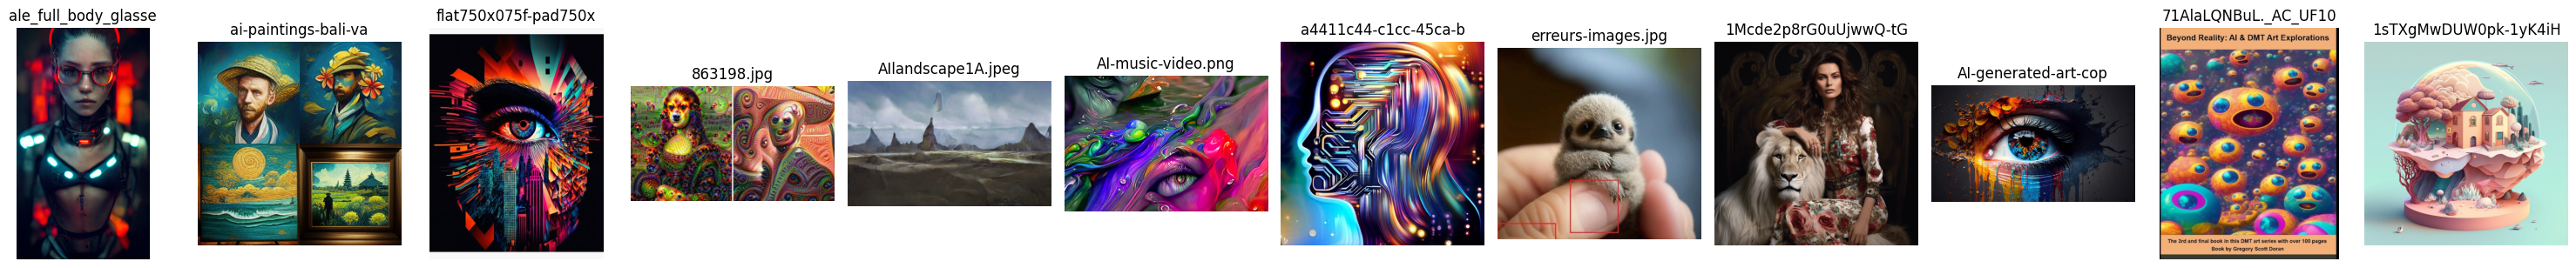

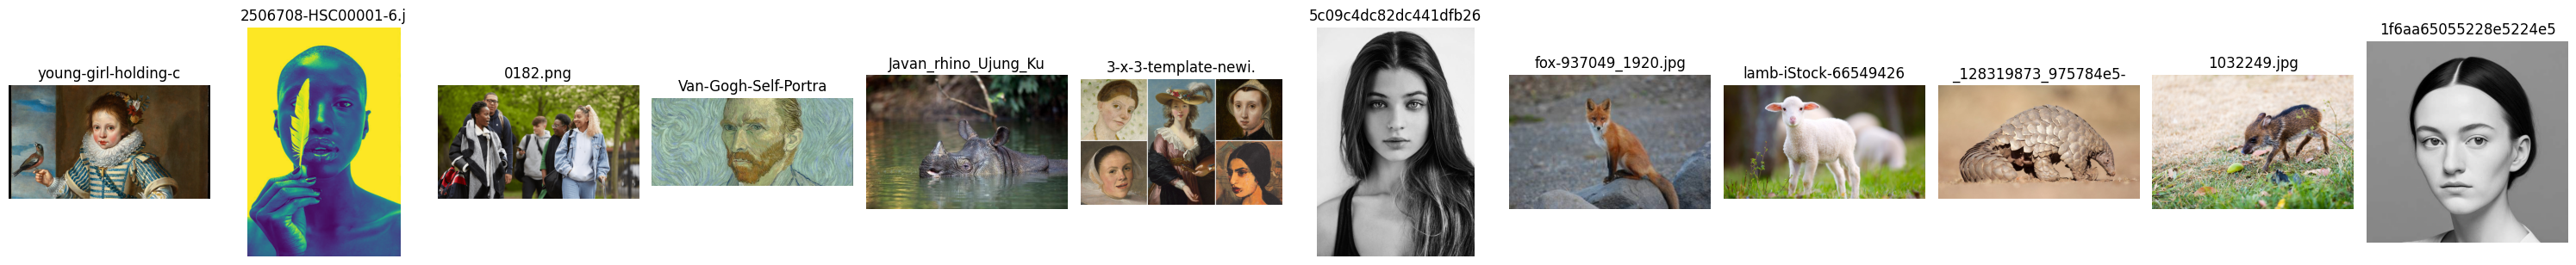

In [8]:
images = 12


def show_images_from_folder(folder, n=10):
    files = [
        f
        for f in os.listdir(folder)
        if f.lower().endswith(("jpg", "jpeg", "png"))
    ]
    plt.figure(figsize=(30, 6))
    for i, file in enumerate(files[:n]):
        img = Image.open(os.path.join(folder, file))
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(file[:20])
    plt.tight_layout()
    plt.show()


# ПРОВЕРКА текущей директории
print("Текущая папка:", os.getcwd())
print("Доступные папки:", os.listdir("."))

show_images_from_folder("./data/AiArtData", images)
show_images_from_folder("./data/RealArt", images)


# Аугментации

In [9]:
def get_image_paths_and_labels(root_dir):
    """Сбор путей и классов"""
    classes = sorted(
        [
            d
            for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ]
    )
    image_paths, labels = [], []

    for idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(("jpg", "png", "jpeg"))
        ]
        image_paths.extend(files)
        labels.extend([idx] * len(files))

    print(f"Найдено {len(image_paths)} изображений, классы: {classes}")
    return image_paths, labels, classes


def compute_mean_std_cached(image_paths, cache_file="stats_cache.pkl"):
    """Вычисление или загрузка кэшированных статистик"""
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            mean, std = pickle.load(f)
        print(f"Загружены кэшированные статистики: {cache_file}")
        return mean, std

    print("Вычисляем статистики...")
    means, stds = [], []

    for path in tqdm(image_paths, desc="Stats"):
        try:
            img = Image.open(path).convert("RGB")
            img = np.array(img) / 255.0
            means.append(np.mean(img, axis=(0, 1)))
            stds.append(np.std(img, axis=(0, 1)))
        except Exception:
            continue

    mean, std = np.mean(means, axis=0), np.mean(stds, axis=0)

    with open(cache_file, "wb") as f:
        pickle.dump((mean, std), f)

    print(f"Сохранены статистики: {cache_file}")
    return mean, std


root_dir = "./data"
image_paths, labels, classes = get_image_paths_and_labels(root_dir)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=2468
)

mean, std = compute_mean_std_cached(train_paths)
print(f"Mean: {mean}")
print(f"Std: {std}")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")


Найдено 968 изображений, классы: ['AiArtData', 'RealArt']
Вычисляем статистики...


Stats: 100%|██████████| 774/774 [02:01<00:00,  6.39it/s]

Сохранены статистики: stats_cache.pkl
Mean: [0.45558014 0.42318492 0.392566  ]
Std: [0.2621987  0.24038664 0.23456734]
Train: 774 | Val: 194


Train: 774 изображений
Val: 194 изображений


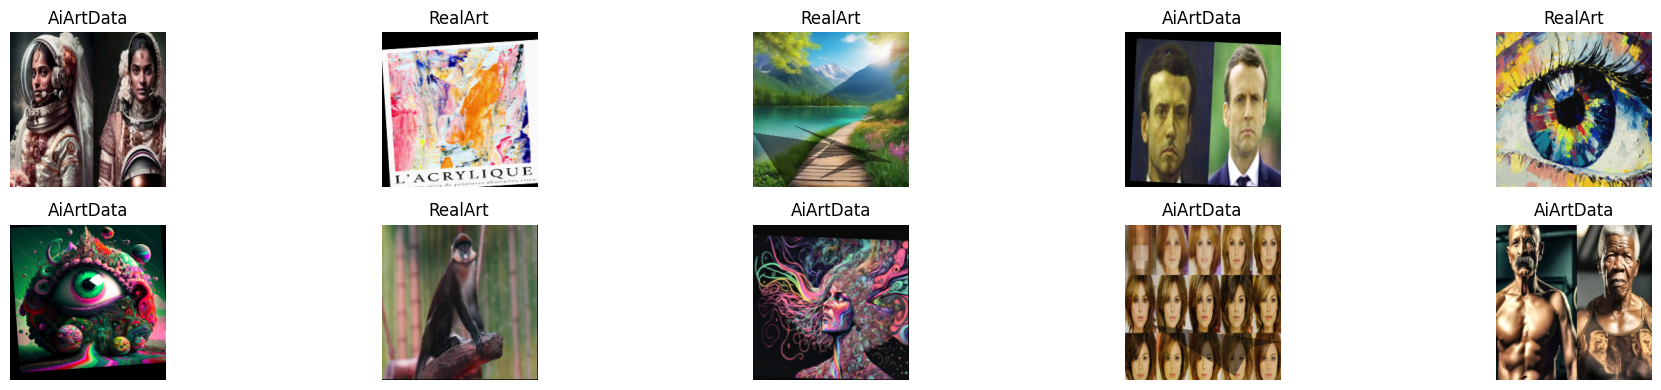

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
            label = self.labels[idx]
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented["image"]
            return image, label
        except Exception:
            # Fallback для битых изображений
            return torch.zeros(3, 224, 224), self.labels[idx]


# Используем точные статистики из предыдущей ячейки
MEAN = [0.4556, 0.4232, 0.3926]
STD = [0.2622, 0.2404, 0.2346]

train_transform = A.Compose(
    [
        A.Resize(height=256, width=256),
        A.RandomResizedCrop(
            scale=(0.8, 1.0), size=(224, 224), p=1.0
        ),  # 224 для ResNet
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=5, p=0.5
        ),
        A.ColorJitter(
            brightness=0.15, contrast=0.2, saturation=0.2, hue=0.1, p=0.8
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.03, p=0.2),
        A.OpticalDistortion(distort_limit=0.05, p=0.2),
        A.RandomShadow(p=0.2),
        A.RandomBrightnessContrast(
            brightness_limit=0.1, contrast_limit=0.1, p=0.3
        ),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),
        A.Normalize(mean=MEAN, std=STD),  # Точные значения
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(height=256, width=256),
        A.CenterCrop(224, 224),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ]
)

# DataLoader с оптимизацией
train_loader = DataLoader(
    CustomImageDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    CustomImageDataset(val_paths, val_labels, val_transform),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


def show_batch(data_loader, classes, n=10):
    images, labels = next(iter(data_loader))
    plt.figure(figsize=(20, 4))
    for i in range(min(n, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img * np.array(STD) + np.array(MEAN)  # denorm
        img = np.clip(img, 0, 1)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img)
        plt.title(classes[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


print(f"Train: {len(train_loader.dataset)} изображений")
print(f"Val: {len(val_loader.dataset)} изображений")
show_batch(train_loader, classes)

# Вариант 1: Собственная небольшая сверточная сеть, собранная из блоков (пример — как в практическом ноутбуке).



In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1, s=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_ch, out_ch, kernel_size=k, padding=p, stride=s, bias=False
        )
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = F.relu(x, inplace=True)
        return x


# Дополнительно: Residual версия (улучшает градиенты)
class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBlock(in_ch, out_ch // 2)
        self.conv2 = ConvBlock(out_ch // 2, out_ch)

        # Skip connection
        self.shortcut = (
            nn.Conv2d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch
            else nn.Identity()
        )
        self.bn_shortcut = (
            nn.BatchNorm2d(out_ch) if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        identity = self.bn_shortcut(identity)

        out = self.conv1(x)
        out = self.conv2(out)

        return F.relu(out + identity, inplace=True)

In [12]:
# A100 оптимизация
torch.set_float32_matmul_precision("high")


class SimpleCNN(L.LightningModule):
    def __init__(
        self, num_classes=2, lr=3e-4, weight_decay=1e-4, steps_per_epoch=24
    ):
        super().__init__()
        self.save_hyperparameters()

        self.features = nn.Sequential(
            ConvBlock(3, 16),
            ConvBlock(16, 16),
            nn.MaxPool2d(2),  # 224->112
            ConvBlock(16, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2),  # 112->56
            ConvBlock(32, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),  # 56->28
            ConvBlock(64, 128),
            ConvBlock(128, 128),
            nn.MaxPool2d(2),  # 28->14
            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool2d(2),  # 14->7
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self.train_metrics = nn.ModuleDict(
            {
                "acc": tm.classification.Accuracy(task="binary"),
                "prec": tm.classification.Precision(task="binary"),
                "rec": tm.classification.Recall(task="binary"),
                "f1": tm.classification.F1Score(task="binary"),
            }
        )
        self.val_metrics = nn.ModuleDict(
            {
                "acc": tm.classification.Accuracy(task="binary"),
                "prec": tm.classification.Precision(task="binary"),
                "rec": tm.classification.Recall(task="binary"),
                "f1": tm.classification.F1Score(task="binary"),
            }
        )
        self.test_metrics = nn.ModuleDict(
            {
                "acc": tm.classification.Accuracy(task="binary"),
                "prec": tm.classification.Precision(task="binary"),
                "rec": tm.classification.Recall(task="binary"),
                "f1": tm.classification.F1Score(task="binary"),
            }
        )

    def forward(self, x):
        return self.head(self.features(x))

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.hparams.lr,
            epochs=self.trainer.max_epochs,
            steps_per_epoch=self.hparams.steps_per_epoch,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def _common_step(self, batch, stage, metrics_dict):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)

        # Метрики автоматически на том же device что и модель
        for metric_name, metric in metrics_dict.items():
            score = metric(preds, y)
            self.log(
                f"{stage}_{metric_name}",
                score,
                on_epoch=True,
                prog_bar=(stage == "train"),
            )

        self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, "train", self.train_metrics)

    def validation_step(self, batch, batch_idx):
        self._common_step(batch, "val", self.val_metrics)

    def test_step(self, batch, batch_idx):
        self._common_step(batch, "test", self.test_metrics)


In [13]:
model = SimpleCNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")


Всего параметров: 1,180,786


In [14]:
class ArtVsAIDataModule(L.LightningDataModule):
    def __init__(self, train_loader, val_loader):
        super().__init__()
        self._train_loader = train_loader
        self._val_loader = val_loader

    def train_dataloader(self):
        return self._train_loader

    def val_dataloader(self):
        return self._val_loader


# Параметры обучения
EPOCHS = 15
steps_per_epoch = len(train_loader)
print(f"Steps per epoch: {steps_per_epoch}")

# Модель
model = SimpleCNN(
    num_classes=2, lr=3e-3, weight_decay=1e-4, steps_per_epoch=steps_per_epoch
)

# Логгер и колбэки
logger = CSVLogger(save_dir="logs", name="cnn_art_vs_ai")

callbacks = [
    ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename="cnn-{epoch:02d}-{val_acc:.4f}",
        save_last=True,  # Сохраняем последний чекпойнт
    ),
    LearningRateMonitor(logging_interval="step"),
    RichProgressBar(),
]

# Трейнер с улучшениями
trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",  # Явно GPU
    devices=1,  # 1 GPU
    precision="16-mixed",  # AMP для скорости
    logger=logger,
    callbacks=callbacks,
    deterministic="warn",  # Проверка seed
    log_every_n_steps=10,  # Реже логирование
    enable_checkpointing=True,
)

# DataModule и обучение
datamodule = ArtVsAIDataModule(train_loader, val_loader)
trainer.fit(model, datamodule=datamodule)

print("Лучший чекпойнт:", callbacks[0].best_model_path)

# Тестирование на лучшем чекпойнте
trainer.test(model, dataloaders=val_loader, ckpt_path="best")


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Steps per epoch: 25


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features      │ Sequential │  1.2 M │ train │     0 │
│ 1 │ head          │ Sequential │  1.0 K │ train │     0 │
│ 2 │ train_metrics │ ModuleDict │      0 │ train │     0 │
│ 3 │ val_metrics   │ ModuleDict │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleDict │      0 │ train │     0 │
└───┴───────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Restoring states from the checkpoint path at logs/cnn_art_vs_ai/version_0/checkpoints/cnn-epoch=12-val_acc=0.7474.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at logs/cnn_art_vs_ai/version_0/checkpoints/cnn-epoch=12-val_acc=0.7474.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at logs/cnn_art_vs_ai/version_0/checkpoints/cnn-epoch=12-val_acc=0.7474.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at logs/cnn_art_vs_ai/version_0/checkpoints/cnn-epoch=12-val_acc=0.7474.ckpt


Лучший чекпойнт: logs/cnn_art_vs_ai/version_0/checkpoints/cnn-epoch=12-val_acc=0.7474.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7474226951599121     │
│          test_f1          │    0.7089959383010864     │
│         test_loss         │    0.5362123847007751     │
│         test_prec         │    0.7431206703186035     │
│         test_rec          │    0.6909595727920532     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.7474226951599121,
  'test_prec': 0.7431206703186035,
  'test_rec': 0.6909595727920532,
  'test_f1': 0.7089959383010864,
  'test_loss': 0.5362123847007751}]

# Функции визуализация результатов

In [15]:
def plot_training_metrics_pro(
    log_dir, version=3, model_name="Model", figsize=(16, 6)
):
    """
    Универсальная визуализация
    """
    # Cтиль
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    colors = sns.color_palette("husl", 4)

    # Загружаем метрики
    log_path = Path(log_dir) / f"version_{version}"
    metrics_path = log_path / "metrics.csv"
    print(f"Логи: {metrics_path}")

    df = pd.read_csv(metrics_path)
    df = df.dropna(subset=["step"])

    # Показываем таблицу
    display_cols = [
        col
        for col in [
            "epoch",
            "train_loss",
            "train_loss_epoch",
            "train_acc",
            "train_acc_epoch",
            "val_loss",
            "val_acc",
            "val_f1",
        ]
        if col in df.columns
    ]
    print("\nПоследние 10 эпох:")
    print(df[display_cols].tail(10).round(4))

    # Универсальная фильтрация для Lightning форматов
    if "train_loss_epoch" in df.columns and "train_acc_epoch" in df.columns:
        train_epochs = df.dropna(
            subset=["train_loss_epoch", "train_acc_epoch"]
        ).copy()
    else:
        train_epochs = df.dropna(subset=["train_loss", "train_acc"]).copy()

    val_epochs = df.dropna(subset=["val_loss", "val_acc"]).copy()

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(
        f"{model_name}: Training Progress",
        fontsize=20,
        fontweight="bold",
        y=1.02,
    )

    # Loss график (универсальный)
    train_loss_col = (
        "train_loss_epoch"
        if "train_loss_epoch" in df.columns
        else "train_loss"
    )
    train_acc_col = (
        "train_acc_epoch" if "train_acc_epoch" in df.columns else "train_acc"
    )

    ax1.plot(
        train_epochs["epoch"],
        train_epochs[train_loss_col],
        marker="o",
        markersize=10,
        linewidth=4,
        label="Train Loss",
        color=colors[0],
        markerfacecolor="white",
        markeredgewidth=3,
        markeredgecolor=colors[0],
    )

    ax1.plot(
        val_epochs["epoch"],
        val_epochs["val_loss"],
        marker="s",
        markersize=10,
        linewidth=4,
        label="Val Loss",
        color=colors[1],
        markerfacecolor="white",
        markeredgewidth=3,
        markeredgecolor=colors[1],
    )
    ax1.set_title("Loss Evolution", fontsize=16, fontweight="bold", pad=20)
    ax1.set_xlabel("Epoch", fontsize=14)
    ax1.set_ylabel("Loss", fontsize=14)
    ax1.legend(fontsize=12, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor("#f8f9fa")

    # Accuracy график
    ax2.plot(
        train_epochs["epoch"],
        train_epochs[train_acc_col],
        marker="o",
        markersize=10,
        linewidth=4,
        label="Train Accuracy",
        color=colors[2],
        markerfacecolor="white",
        markeredgewidth=3,
        markeredgecolor=colors[2],
    )

    ax2.plot(
        val_epochs["epoch"],
        val_epochs["val_acc"],
        marker="s",
        markersize=10,
        linewidth=4,
        label="Val Accuracy",
        color=colors[3],
        markerfacecolor="white",
        markeredgewidth=3,
        markeredgecolor=colors[3],
    )
    ax2.set_title("Accuracy Evolution", fontsize=16, fontweight="bold", pad=20)
    ax2.set_xlabel("Epoch", fontsize=14)
    ax2.set_ylabel("Accuracy", fontsize=14)
    ax2.legend(fontsize=12, frameon=True, shadow=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor("#f8f9fa")

    # Аннотация лучшего результата
    best_val_idx = val_epochs["val_acc"].idxmax()
    best_val_epoch = val_epochs.loc[best_val_idx, "epoch"]
    best_val_acc = val_epochs.loc[best_val_idx, "val_acc"]
    ax2.annotate(
        f"Best: {best_val_acc:.1%}\nEpoch {best_val_epoch:.0f}",
        xy=(best_val_epoch, best_val_acc),
        xytext=(8, 0.85),
        arrowprops=dict(arrowstyle="->", color=colors[3], lw=2),
        fontsize=12,
        ha="center",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
    )

    plt.tight_layout()
    plt.show()

    # Итоговая сводка
    print(f"{model_name} РЕЗУЛЬТАТЫ")
    print(f"Лучшая val_acc: {best_val_acc:.1%} (эпоха {best_val_epoch:.0f})")
    print(f"Финальная val_acc: {val_epochs['val_acc'].iloc[-1]:.1%}")
    if "val_f1" in df.columns:
        print(f"Лучшая val_f1: {df['val_f1'].max():.1%}")
    print(f"Эпох всего: {len(val_epochs)}")


def plot_confusion_matrix(
    model,
    val_loader,
    classes,
    model_name="Model",
    checkpoint_path=None,
    device=None,
    figsize=(12, 10),
):
    """
    Универсальная функция построения confusion matrix для любой
    Lightning модели.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Загрузка модели
    if checkpoint_path:
        print(f"Загрузка модели из чекпоинта: {checkpoint_path}")
        model = type(model).__class__.load_from_checkpoint(checkpoint_path)

    model.eval().to(device)
    print(f"Модель {model_name} загружена на устройство: {device}")

    # Предсказания
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_targets.append(yb)

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    print(f"Размер валидации: {len(all_targets)}")
    print(f"Классы: {classes}")
    print(f"Распределение классов: {np.bincount(all_targets)}")

    # Матрица ошибок
    cm = confusion_matrix(all_targets, all_preds)
    acc = (np.trace(cm) / np.sum(cm)) * 100

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={"shrink": 0.8},
        linewidths=2,
        linecolor="white",
        square=True,
    )

    plt.title(
        f"{model_name}: Confusion Matrix (Validation)\nAccuracy: {acc:.2f}%",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Предсказанные классы", fontsize=14, fontweight="bold")
    plt.ylabel("Истинные классы", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    # Precision / Recall по каждому классу
    for i in range(len(classes)):
        col_sum = cm[:, i].sum()
        row_sum = cm[i, :].sum()
        if col_sum > 0:
            prec = cm[i, i] / col_sum * 100
            plt.text(
                i + 0.5,
                -0.2,
                f"P: {prec:.0f}%",
                ha="center",
                va="top",
                fontweight="bold",
                fontsize=12,
                transform=plt.gca().get_xaxis_transform(),
            )
        if row_sum > 0:
            rec = cm[i, i] / row_sum * 100
            plt.text(
                -0.15,
                i + 0.5,
                f"R: {rec:.0f}%",
                ha="right",
                va="center",
                fontweight="bold",
                fontsize=12,
                rotation=90,
                transform=plt.gca().get_yaxis_transform(),
            )

    plt.tight_layout()
    plt.show()

    # Метрики по классам (ИСПРАВЛЕНО форматирование)
    print("\n" + "=" * 60)
    print(f"{model_name} | Метрики по классам")
    print("=" * 60)

    tn, fp, fn, tp = cm.ravel()
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_0 = (
        2 * precision_0 * recall_0 / (precision_0 + recall_0)
        if (precision_0 + recall_0) > 0
        else 0
    )
    f1_1 = (
        2 * precision_1 * recall_1 / (precision_1 + recall_1)
        if (precision_1 + recall_1) > 0
        else 0
    )

    print(f"{'Класс':<20} {classes[0]:<15} | {classes[1]:<15}")
    print(
        (
            f"{'Precision:':<20} {precision_0 * 100:6.1f}% "
            f"| {precision_1 * 100:6.1f}%"
        )
    )
    print(
        f"{'Recall:':<20}    {recall_0 * 100:6.1f}% | {recall_1 * 100:6.1f}%"
    )
    print(f"{'F1-score:':<20}   {f1_0 * 100:6.1f}% | {f1_1 * 100:6.1f}%")
    print(f"{'Support:':<20}    {cm[0].sum():<10} | {cm[1].sum():<10}")
    print("=" * 60)


def unnormalize(
    img, mean=(0.4556, 0.4232, 0.3926), std=(0.2622, 0.2404, 0.2346)
):
    m = torch.tensor(mean)[:, None, None]
    s = torch.tensor(std)[:, None, None]
    return (img * s + m).clamp(0, 1)


def analyze_errors(
    model_class,
    checkpoint_path,
    val_dataset,
    val_loader,
    classes,
    model_name,
    callbacks=None,
):
    """Универсальный анализ ошибок для любой модели"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Загрузка модели
    model = model_class.load_from_checkpoint(checkpoint_path)
    model.eval().to(device)

    print(f"Анализ ошибок {model_name}")

    # Предсказания (NUMPY)
    all_preds_list, all_targets_list = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu()
            all_preds_list.append(preds)
            all_targets_list.append(yb)

    all_preds = torch.cat(all_preds_list).numpy()
    all_targets = torch.cat(all_targets_list).numpy()

    total_errors = (all_preds != all_targets).sum()
    error_rate = total_errors / len(all_targets) * 100
    print(
        f"Всего ошибок: {total_errors}/{len(all_targets)} ({error_rate:.1f}%)"
    )

    N = min(16, total_errors)
    wrong_idx = np.where(all_preds != all_targets)[0][:N]

    if len(wrong_idx) > 0:
        imgs, true_labels, pred_labels = [], [], []

        for i in wrong_idx:
            img, true_label = val_dataset[i]
            img = img.unsqueeze(0).to(device)

            with torch.no_grad():
                logits = model(img)
                pred_label = logits.argmax(dim=1).cpu().item()

            imgs.append(unnormalize(img.squeeze(0).cpu()))
            true_labels.append(true_label)
            pred_labels.append(pred_label)

        # График
        grid = vutils.make_grid(torch.stack(imgs), nrow=8, padding=8)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        fig.suptitle(
            f"Ошибки {model_name} ({error_rate:.1f}% error rate)",
            fontsize=18,
            fontweight="bold",
        )

        ax1.imshow(grid.permute(1, 2, 0).cpu().numpy())
        ax1.set_title(
            f"Ошибочные изображения (N={len(imgs)})",
            fontsize=14,
            fontweight="bold",
        )
        ax1.axis("off")

        # Типы ошибок
        real_to_ai = sum(
            t == 0 and p == 1 for t, p in zip(true_labels, pred_labels)
        )
        ai_to_real = sum(
            t == 1 and p == 0 for t, p in zip(true_labels, pred_labels)
        )

        error_types = ["Real→AI", "AI→Real"]
        error_counts = [real_to_ai, ai_to_real]

        bars = ax2.bar(
            error_types,
            error_counts,
            color=["#ff6b6b", "#4ecdc4"],
            alpha=0.8,
            edgecolor="white",
            linewidth=3,
        )
        ax2.set_title("Типы ошибок", fontsize=14, fontweight="bold")
        ax2.set_ylabel("Количество")

        for bar, count in zip(bars, error_counts):
            height = bar.get_height()
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.02,
                f"{count}",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=14,
            )
        ax2.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print("\nПЕРВЫЕ 8 ОШИБОК:")
        print("-" * 40)
        for i in range(min(8, len(true_labels))):
            print(
                (
                    f"#{i + 1}: {classes[true_labels[i]]} "
                    f"→ {classes[pred_labels[i]]}"
                )
            )
    else:
        print("Ошибок не найдено!")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Логи: logs/cnn_art_vs_ai/version_0/metrics.csv

Последние 10 эпох:
     epoch  train_loss_epoch  train_acc_epoch  val_loss  val_acc  val_f1
95    13.0               NaN              NaN       NaN      NaN     NaN
96    13.0               NaN              NaN    0.5300   0.7216  0.6752
97    13.0            0.6059           0.6654       NaN      NaN     NaN
98     NaN               NaN              NaN       NaN      NaN     NaN
99    14.0               NaN              NaN       NaN      NaN     NaN
100    NaN               NaN              NaN       NaN      NaN     NaN
101   14.0               NaN              NaN       NaN      NaN     NaN
102   14.0               NaN              NaN    0.5346   0.7268  0.6877
103   14.0            0.5886           0.6938       NaN      NaN     NaN
104   15.0               NaN              NaN       NaN      NaN     NaN


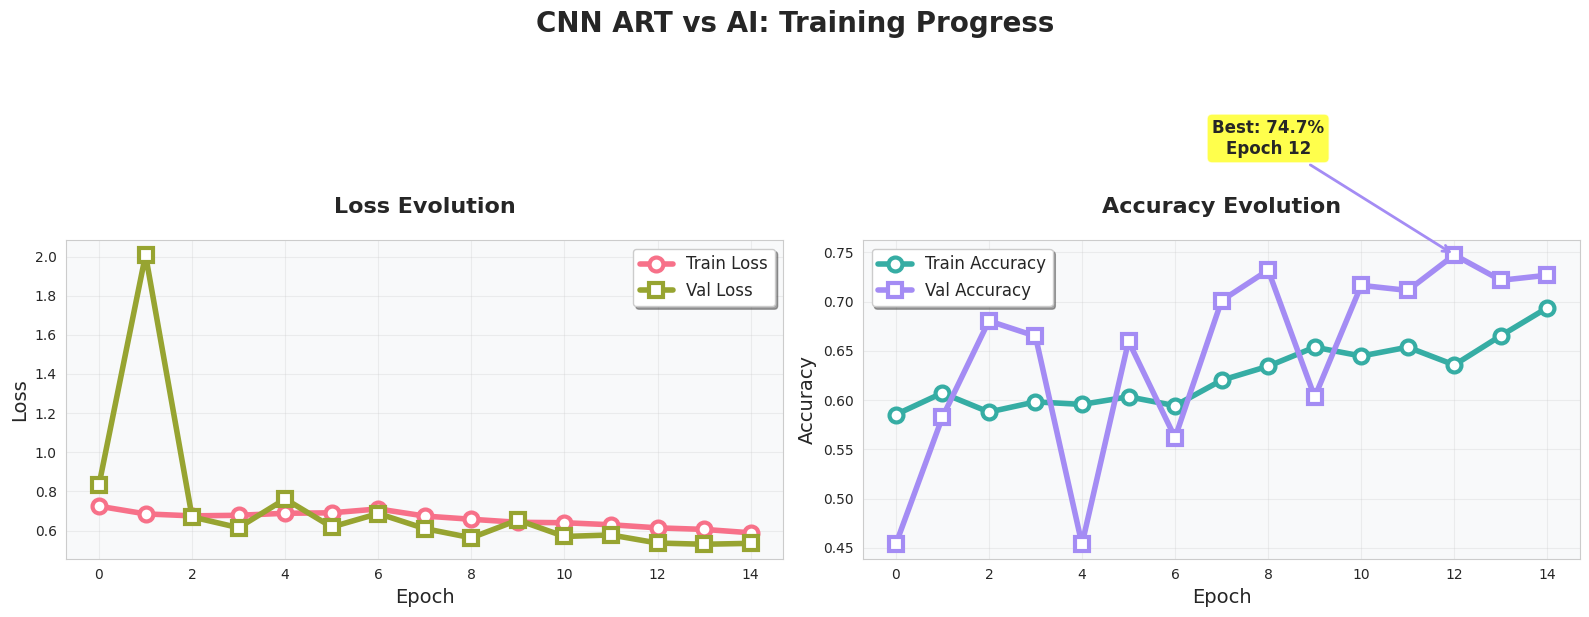

CNN ART vs AI РЕЗУЛЬТАТЫ
Лучшая val_acc: 74.7% (эпоха 12)
Финальная val_acc: 72.7%
Лучшая val_f1: 72.0%
Эпох всего: 15


In [16]:
plot_training_metrics_pro(
    "logs/cnn_art_vs_ai", version=0, model_name="CNN ART vs AI"
)

Модель CNN ART vs AI загружена на устройство: cuda
Размер валидации: 194
Классы: ['AiArtData', 'RealArt']
Распределение классов: [107  87]


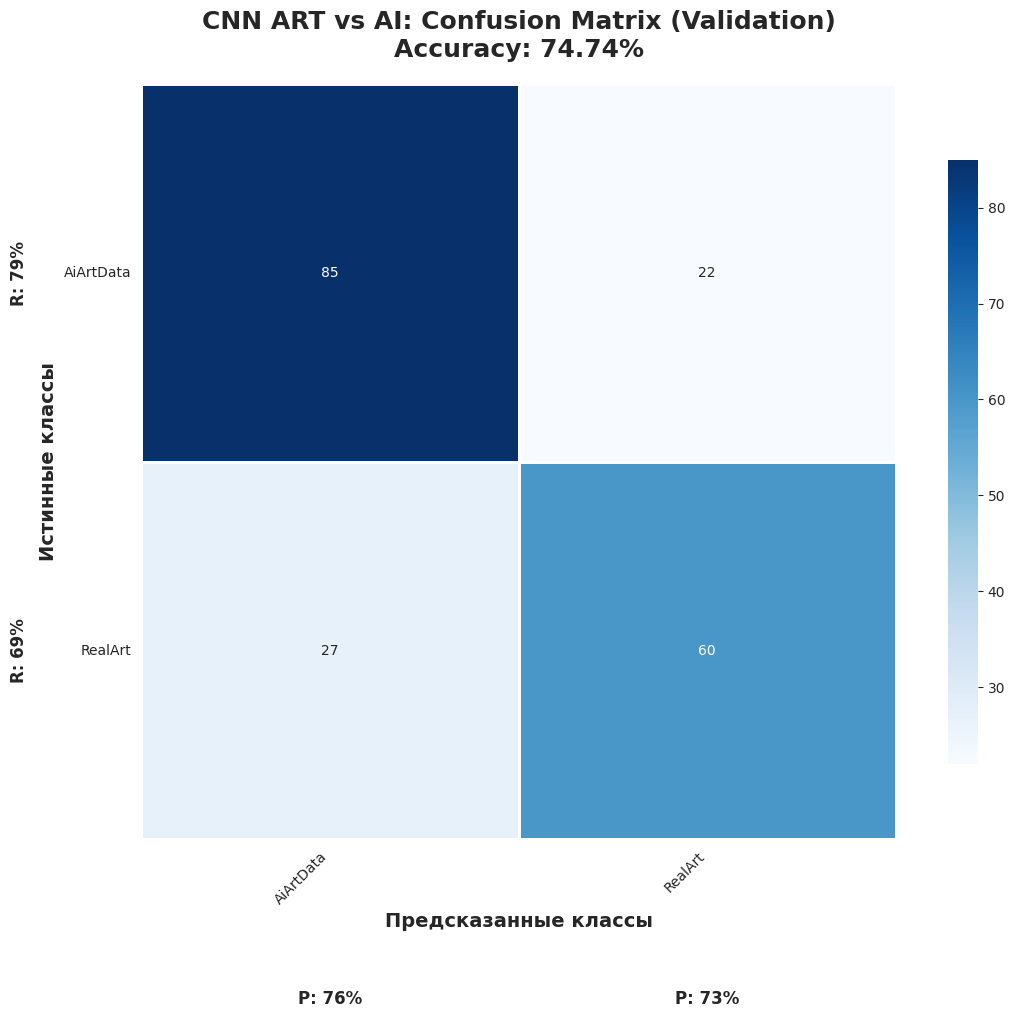


CNN ART vs AI | Метрики по классам
Класс                AiArtData       | RealArt        
Precision:             75.9% |   73.2%
Recall:                   79.4% |   69.0%
F1-score:                77.6% |   71.0%
Support:                107        | 87        


In [17]:
cnn_checkpoint = "logs/cnn_art_vs_ai/version_0/checkpoints/last.ckpt"
cnn_model = SimpleCNN.load_from_checkpoint(cnn_checkpoint)
plot_confusion_matrix(
    cnn_model, val_loader, classes, model_name="CNN ART vs AI", device=device
)

In [ ]:
metrics_df = pd.read_csv("logs/cnn_art_vs_ai/version_0/metrics.csv")
best_val_acc = metrics_df["val_acc"].max()
model_name = f"SimpleCNN ({best_val_acc:.1%})"

print(f"Лучшая val_acc из логов: {model_name}")


Лучшая val_acc из логов: SimpleCNN (74.7%)


Анализ ошибок SimpleCNN (74.7%)
Всего ошибок: 49/194 (25.3%)


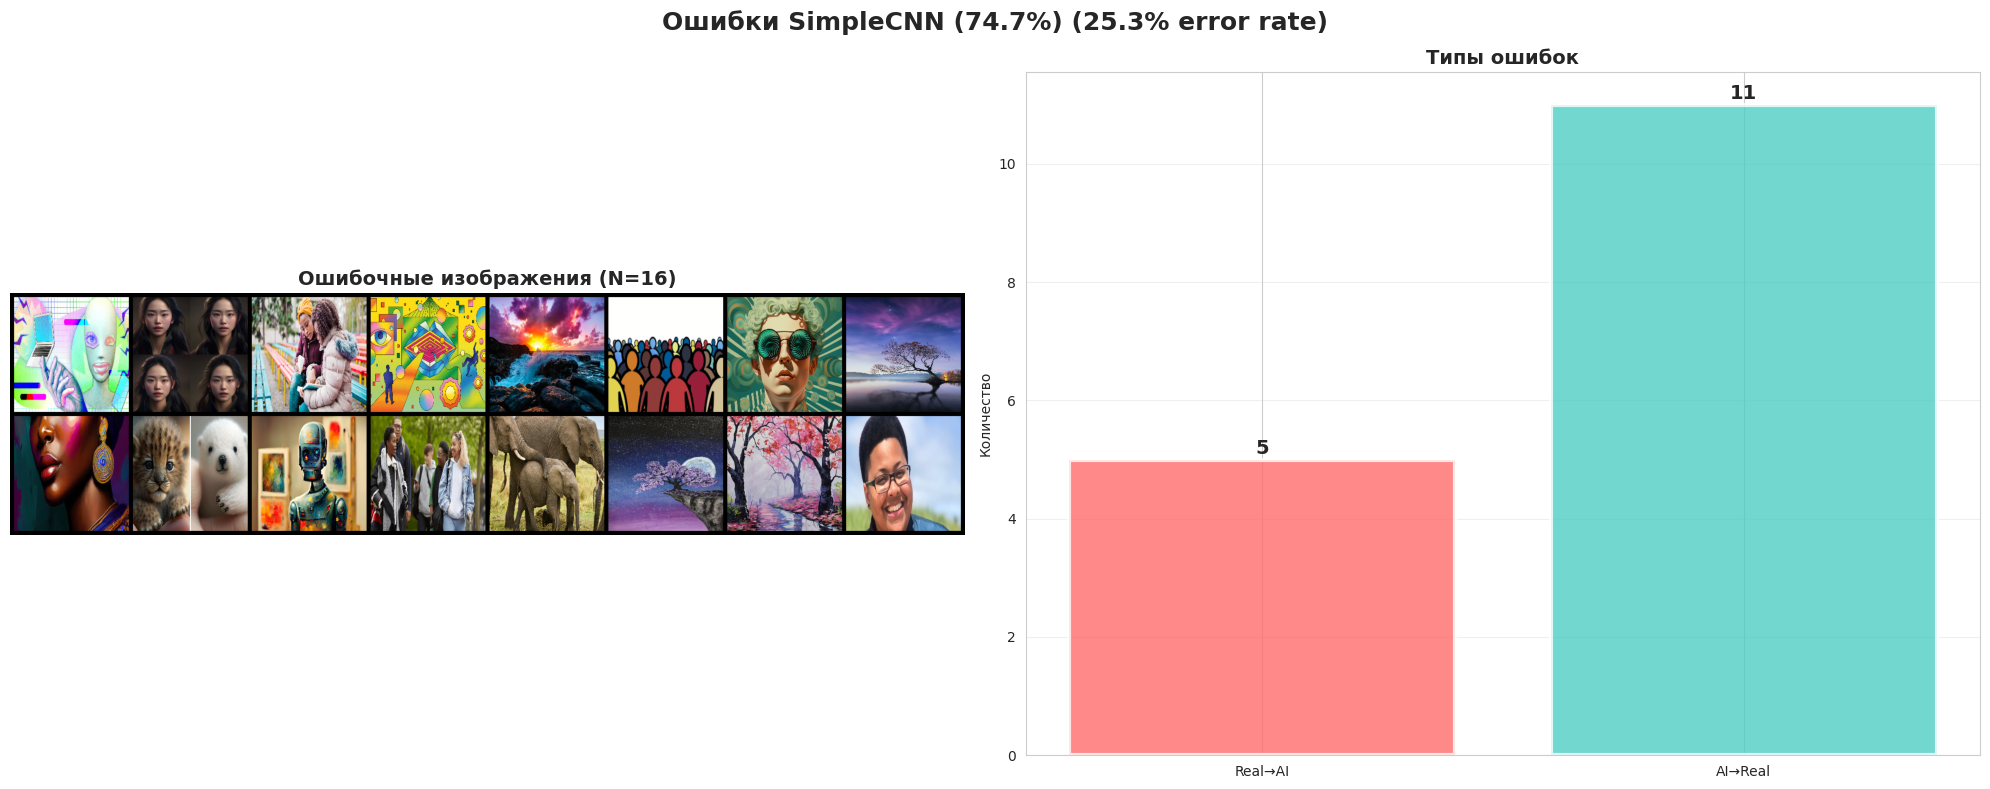


ПЕРВЫЕ 8 ОШИБОК:
----------------------------------------
#1: AiArtData → RealArt
#2: RealArt → AiArtData
#3: RealArt → AiArtData
#4: AiArtData → RealArt
#5: RealArt → AiArtData
#6: RealArt → AiArtData
#7: AiArtData → RealArt
#8: RealArt → AiArtData


In [19]:
# 1. Создаем val_dataset
val_dataset = CustomImageDataset(val_paths, val_labels, val_transform)

# 2. Анализ ошибок
analyze_errors(
    SimpleCNN,
    callbacks[0].best_model_path,
    val_dataset,
    val_loader,
    classes,
    f"SimpleCNN ({best_val_acc:.1%})",
)


# Вариант 2: Полностью обучаемая ResNet-50 (с нуля или с предобученными весами, но с размороженным бэкбоном).комментариями к коду и промежуточными выводами.

In [20]:
class ResNet50Full(L.LightningModule):
    """ResNet50 с полностью обучаемым бэкбоном"""

    def __init__(
        self, num_classes=2, lr=5e-4, weight_decay=1e-4, steps_per_epoch=25
    ):
        super().__init__()
        self.save_hyperparameters()
        print("Создание ResNet50 Full Train...")

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )
        self.backbone.fc = nn.Identity()
        print(
            (
                f"Backbone: "
                f"{sum(p.numel() for p in self.backbone.parameters()):,} "
                f"параметров"
            )
        )

        self.head = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        print(
            (
                f"Head: {sum(p.numel() for p in self.head.parameters()):,} "
                f"параметров"
            )
        )

        for param in self.backbone.parameters():
            param.requires_grad = True
        print("Бэкбон разморожен — все параметры обучаются")

        metrics = {
            "acc": tm.classification.Accuracy(task="binary"),
            "prec": tm.classification.Precision(task="binary"),
            "rec": tm.classification.Recall(task="binary"),
            "f1": tm.classification.F1Score(task="binary"),
        }
        self.train_metrics = nn.ModuleDict(metrics)
        self.val_metrics = nn.ModuleDict(metrics)
        self.test_metrics = nn.ModuleDict(metrics)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
        )
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.hparams.lr,
            epochs=self.trainer.max_epochs,
            steps_per_epoch=self.hparams.steps_per_epoch,
        )
        print(f"Оптимизатор: AdamW lr={self.hparams.lr}")
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def _common_step(self, batch, stage, metrics_dict):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)

        for name, metric in metrics_dict.items():
            self.log(
                f"{stage}_{name}",
                metric(preds, y),
                on_epoch=True,
                prog_bar=(stage == "train"),
            )
        self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, "train", self.train_metrics)

    def validation_step(self, batch, batch_idx):
        self._common_step(batch, "val", self.val_metrics)

    def test_step(self, batch, batch_idx):
        self._common_step(batch, "test", self.test_metrics)


In [21]:
# НАСТРОЙКА И ОБУЧЕНИЕ
print("ВАРИАНТ 2: ResNet50 FULL TRAIN")

EPOCHS = 12
steps_per_epoch = len(train_loader)
print(
    (
        f"Dataset: {len(train_loader.dataset)} train | "
        f"{len(val_loader.dataset)} val"
    )
)
print(f"Steps/epoch: {steps_per_epoch} | Epochs: {EPOCHS}")

model2 = ResNet50Full(
    num_classes=2, lr=5e-4, weight_decay=1e-4, steps_per_epoch=steps_per_epoch
)

logger2 = CSVLogger(save_dir="logs", name="resnet50_full")
callbacks2 = [
    ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename="resnet50_full-e{epoch:02d}-acc{val_acc:.4f}",
        save_last=True,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

trainer2 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",
    devices=1,
    precision="bf16-mixed",
    logger=logger2,
    callbacks=callbacks2,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

print(f"Трейнер готов: A100 bf16 + {EPOCHS} эпох")

print("\nСТАРТ ОБУЧЕНИЯ ResNet50 Full Train...")
datamodule = ArtVsAIDataModule(train_loader, val_loader)
trainer2.fit(model2, datamodule=datamodule)

print("\nОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучший чекпойнт: {callbacks2[0].best_model_path}")

trainer2.test(model2, dataloaders=val_loader, ckpt_path="best")
print(f"\nСохранено: {callbacks2[0].best_model_path}")

ВАРИАНТ 2: ResNet50 FULL TRAIN
Dataset: 774 train | 194 val
Steps/epoch: 25 | Epochs: 12
Создание ResNet50 Full Train...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]
INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Backbone: 23,508,032 параметров
Head: 1,185,026 параметров
Бэкбон разморожен — все параметры обучаются
Трейнер готов: A100 bf16 + 12 эпох

СТАРТ ОБУЧЕНИЯ ResNet50 Full Train...
Оптимизатор: AdamW lr=0.0005


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone      │ ResNet     │ 23.5 M │ train │     0 │
│ 1 │ head          │ Sequential │  1.2 M │ train │     0 │
│ 2 │ train_metrics │ ModuleDict │      0 │ train │     0 │
│ 3 │ val_metrics   │ ModuleDict │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleDict │      0 │ train │     0 │
└───┴───────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 24.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.7 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 167                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...


ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучший чекпойнт: logs/resnet50_full/version_0/checkpoints/resnet50_full-eepoch=08-accval_acc=0.8041.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at logs/resnet50_full/version_0/checkpoints/resnet50_full-eepoch=08-accval_acc=0.8041.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at logs/resnet50_full/version_0/checkpoints/resnet50_full-eepoch=08-accval_acc=0.8041.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8041236996650696     │
│          test_f1          │    0.7672869563102722     │
│         test_loss         │    0.5107805728912354     │
│         test_prec         │    0.8068603277206421     │
│         test_rec          │    0.7446169257164001     │
└───────────────────────────┴───────────────────────────┘


Сохранено: logs/resnet50_full/version_0/checkpoints/resnet50_full-eepoch=08-accval_acc=0.8041.ckpt


Логи: logs/resnet50_full/version_0/metrics.csv

Последние 10 эпох:
    epoch  train_loss_epoch  train_acc_epoch  val_loss  val_acc  val_f1
57   10.0               NaN              NaN       NaN      NaN     NaN
58   10.0               NaN              NaN    0.5251   0.8041  0.7713
59   10.0            0.2383           0.9147       NaN      NaN     NaN
60    NaN               NaN              NaN       NaN      NaN     NaN
61   11.0               NaN              NaN       NaN      NaN     NaN
62   11.0               NaN              NaN       NaN      NaN     NaN
63   11.0               NaN              NaN       NaN      NaN     NaN
64   11.0               NaN              NaN    0.5701   0.7938  0.7523
65   11.0            0.2122           0.9096       NaN      NaN     NaN
66   12.0               NaN              NaN       NaN      NaN     NaN


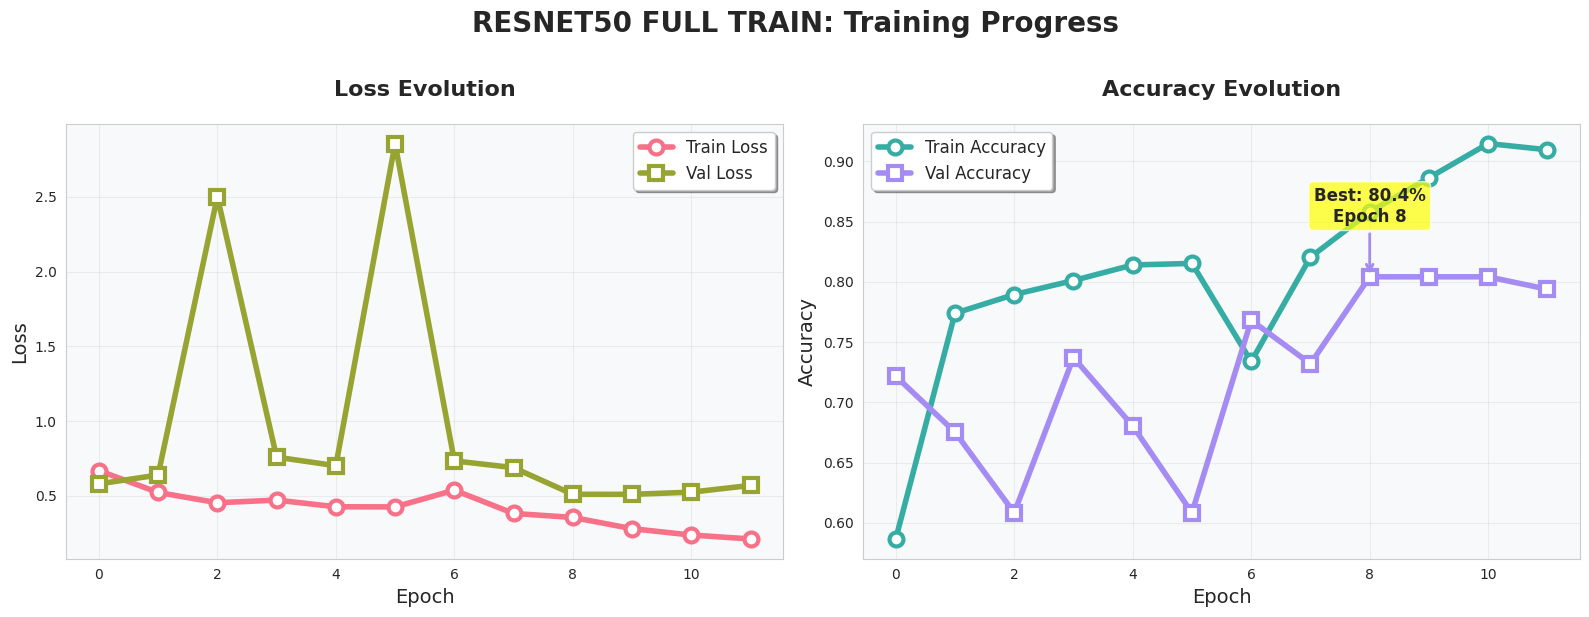

RESNET50 FULL TRAIN РЕЗУЛЬТАТЫ
Лучшая val_acc: 80.4% (эпоха 8)
Финальная val_acc: 79.4%
Лучшая val_f1: 77.9%
Эпох всего: 12


In [22]:
plot_training_metrics_pro(
    "logs/resnet50_full", version=0, model_name="RESNET50 FULL TRAIN"
)

Создание ResNet50 Full Train...
Backbone: 23,508,032 параметров
Head: 1,185,026 параметров
Бэкбон разморожен — все параметры обучаются
Модель RESNET50 FULL TRAIN загружена на устройство: cuda
Размер валидации: 194
Классы: ['AiArtData', 'RealArt']
Распределение классов: [107  87]


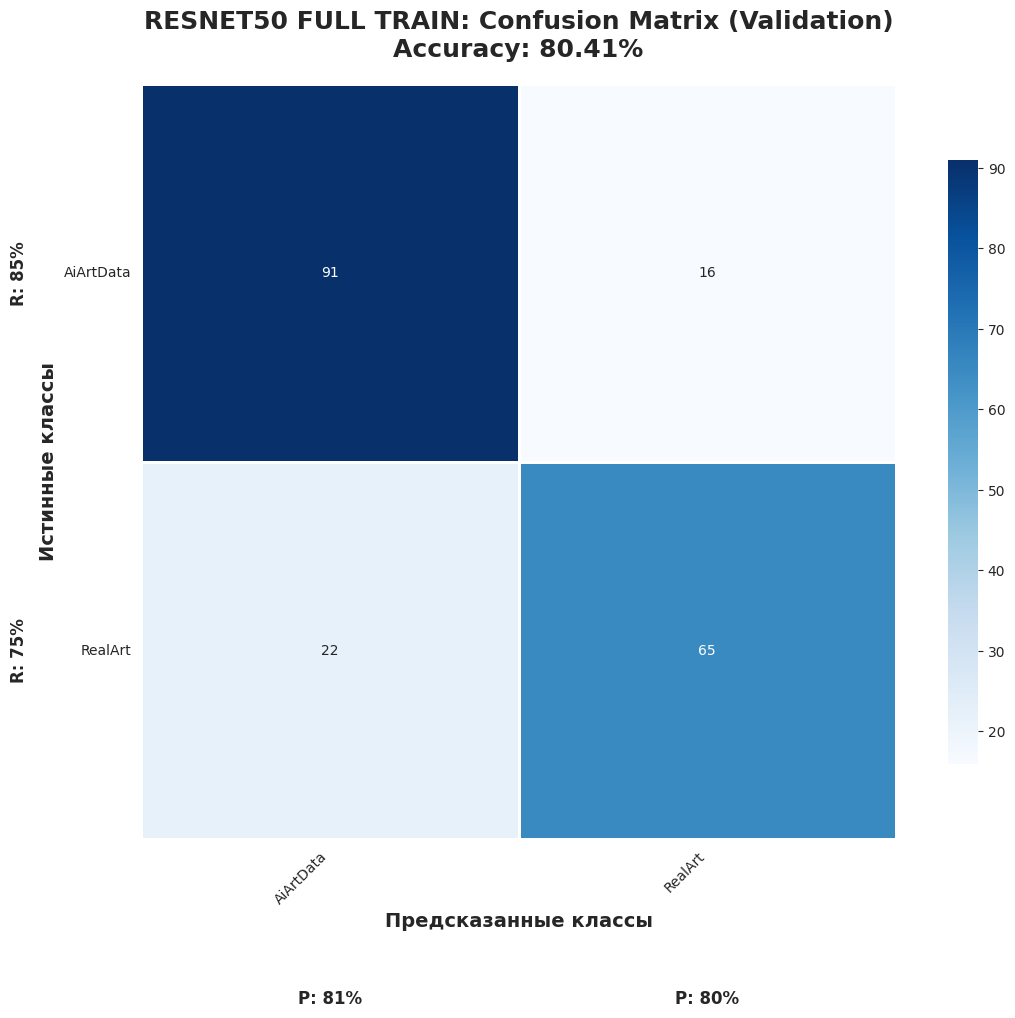


RESNET50 FULL TRAIN | Метрики по классам
Класс                AiArtData       | RealArt        
Precision:             80.5% |   80.2%
Recall:                   85.0% |   74.7%
F1-score:                82.7% |   77.4%
Support:                107        | 87        


In [ ]:
resnet_checkpoint = f"{callbacks2[0].best_model_path}"
resnet_model = ResNet50Full.load_from_checkpoint(resnet_checkpoint)
plot_confusion_matrix(
    resnet_model,
    val_loader,
    classes,
    model_name="RESNET50 FULL TRAIN",
    device=device,
)

In [ ]:
metrics_df = pd.read_csv("logs/resnet50_full/version_0/metrics.csv")
best_val_acc = metrics_df["val_acc"].max()
model_name = f"SimpleCNN ({best_val_acc:.1%})"

print(f"Лучшая val_acc из логов: {model_name}")

Лучшая val_acc из логов: SimpleCNN (80.4%)


Создание ResNet50 Full Train...
Backbone: 23,508,032 параметров
Head: 1,185,026 параметров
Бэкбон разморожен — все параметры обучаются
Анализ ошибок ResNet50 Full (80.4%)
Всего ошибок: 38/194 (19.6%)


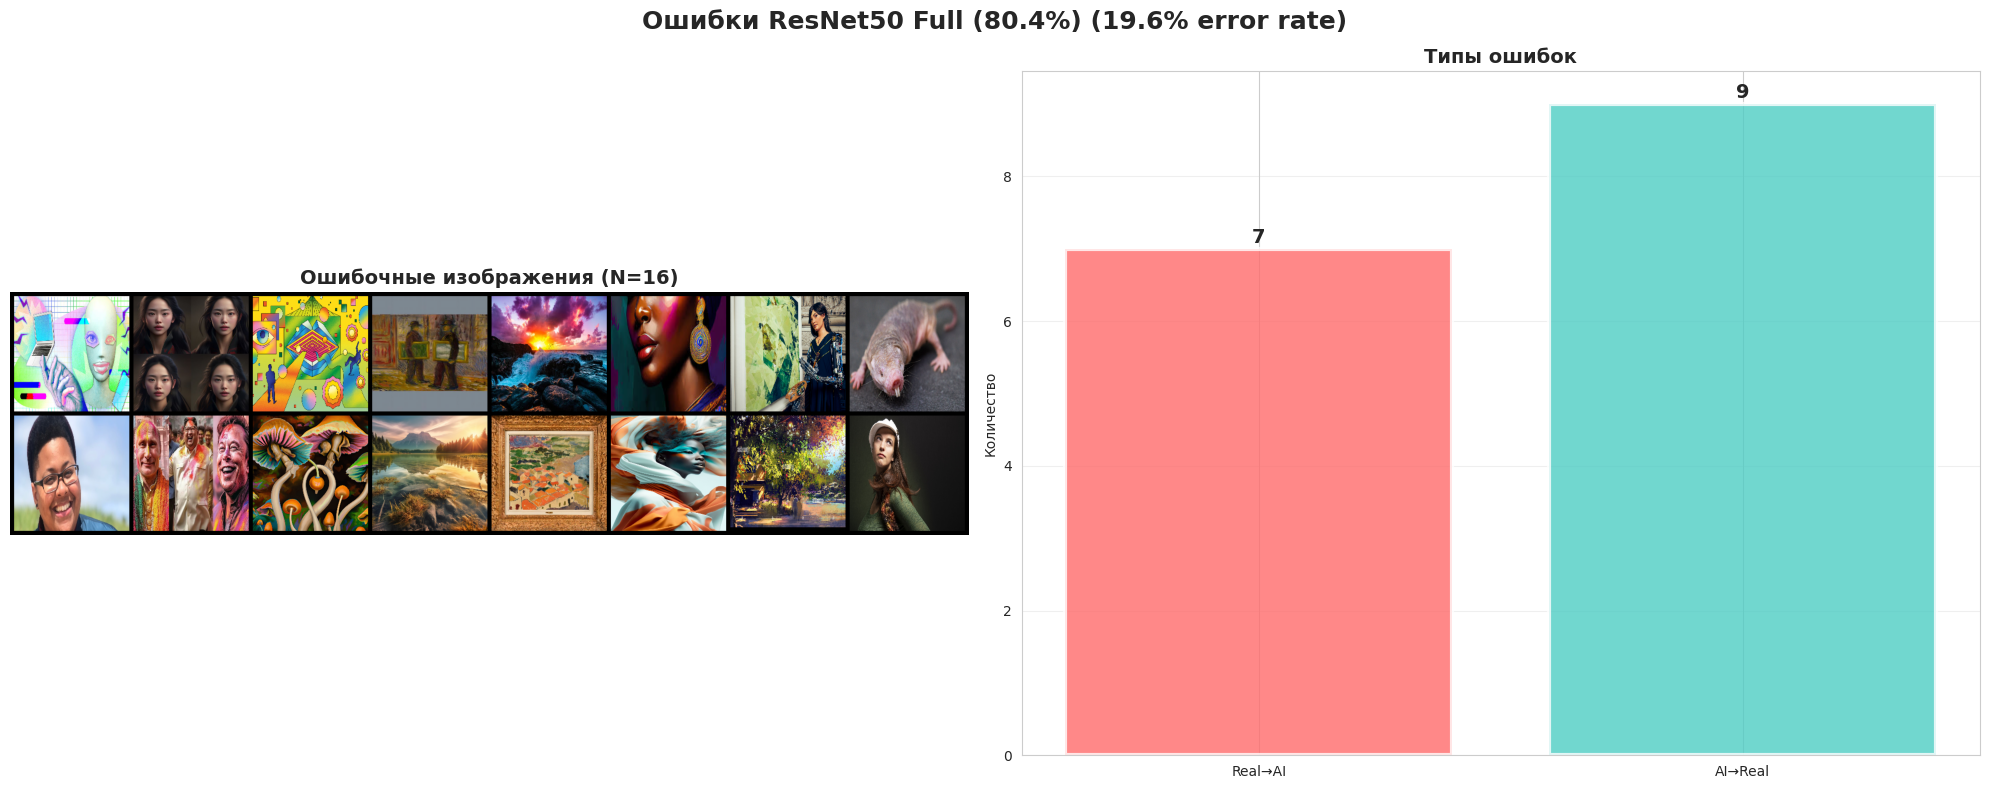


ПЕРВЫЕ 8 ОШИБОК:
----------------------------------------
#1: AiArtData → RealArt
#2: RealArt → AiArtData
#3: AiArtData → RealArt
#4: RealArt → AiArtData
#5: RealArt → AiArtData
#6: RealArt → AiArtData
#7: AiArtData → RealArt
#8: AiArtData → RealArt




In [25]:
analyze_errors(
    ResNet50Full,
    callbacks2[0].best_model_path,
    val_dataset,
    val_loader,
    classes,
    f"ResNet50 Full ({best_val_acc:.1%})",
)
print("\n" + "=" * 80 + "\n")

# Вариант 3: Transfer Learning — используем ResNet-50 с замороженным бэкбоном и обучаем только классификатор (голову).

In [26]:
class ResNet50Frozen(L.LightningModule):
    """ResNet50 с замороженным бэкбоном — обучается только голова"""

    def __init__(
        self, num_classes=2, lr=1e-3, weight_decay=1e-4, steps_per_epoch=25
    ):
        super().__init__()
        self.save_hyperparameters()
        print("Создание ResNet50 Frozen Backbone...")

        # Загружаем предобученную ResNet50
        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )
        self.backbone.fc = nn.Identity()

        # ЗАМОРАЖИВАЕМ БЭКБОН
        for param in self.backbone.parameters():
            param.requires_grad = False

        print(
            (
                f"Backbone заморожен: "
                f"{sum(p.numel() for p in self.backbone.parameters()):,} "
                f"параметров (НЕ обучаются)"
            )
        )

        # Обучаемая голова
        self.head = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.Dropout(0.3),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

        print(
            (
                f"Head (обучается): "
                f"{sum(p.numel() for p in self.head.parameters()):,} "
                f"параметров"
            )
        )

        # Метрики
        metrics = {
            "acc": tm.classification.Accuracy(task="binary"),
            "prec": tm.classification.Precision(task="binary"),
            "rec": tm.classification.Recall(task="binary"),
            "f1": tm.classification.F1Score(task="binary"),
        }
        self.train_metrics = nn.ModuleDict(metrics)
        self.val_metrics = nn.ModuleDict(metrics)
        self.test_metrics = nn.ModuleDict(metrics)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

    def configure_optimizers(self):
        # Оптимизатор ТОЛЬКО для головы
        optimizer = torch.optim.AdamW(
            self.head.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
        )
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.hparams.lr,
            epochs=self.trainer.max_epochs,
            steps_per_epoch=self.hparams.steps_per_epoch,
        )
        print(f"Оптимизатор: AdamW lr={self.hparams.lr} (только голова)")
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def _common_step(self, batch, stage, metrics_dict):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)

        for name, metric in metrics_dict.items():
            self.log(
                f"{stage}_{name}",
                metric(preds, y),
                on_epoch=True,
                prog_bar=(stage == "train"),
            )
        self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, "train", self.train_metrics)

    def validation_step(self, batch, batch_idx):
        self._common_step(batch, "val", self.val_metrics)

    def test_step(self, batch, batch_idx):
        self._common_step(batch, "test", self.test_metrics)


In [27]:
# НАСТРОЙКА И ОБУЧЕНИЕ
print("ВАРИАНТ 3: ResNet50 FROZEN BACKBONE")

EPOCHS = 10
steps_per_epoch = len(train_loader)
print(
    (
        f"Dataset: {len(train_loader.dataset)} train | "
        f"{len(val_loader.dataset)} val"
    )
)
print(f"Steps/epoch: {steps_per_epoch} | Epochs: {EPOCHS}")

model3 = ResNet50Frozen(
    num_classes=2, lr=1e-3, weight_decay=1e-4, steps_per_epoch=steps_per_epoch
)

logger3 = CSVLogger(save_dir="logs", name="resnet50_frozen")
callbacks3 = [
    ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename="resnet50_frozen-e{epoch:02d}-acc{val_acc:.4f}",
        save_last=True,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

trainer3 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",
    devices=1,
    precision="bf16-mixed",
    logger=logger3,
    callbacks=callbacks3,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

print(f"Трейнер готов: A100 bf16 + {EPOCHS} эпох (только голова)")

print("\nСТАРТ ОБУЧЕНИЯ ResNet50 Frozen...")
datamodule = ArtVsAIDataModule(train_loader, val_loader)
trainer3.fit(model3, datamodule=datamodule)

print("\nОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучший чекпойнт: {callbacks3[0].best_model_path}")

trainer3.test(model3, dataloaders=val_loader, ckpt_path="best")
print(f"\nСохранено: {callbacks3[0].best_model_path}")

ВАРИАНТ 3: ResNet50 FROZEN BACKBONE
Dataset: 774 train | 194 val
Steps/epoch: 25 | Epochs: 10
Создание ResNet50 Frozen Backbone...


INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Backbone заморожен: 23,508,032 параметров (НЕ обучаются)
Head (обучается): 1,185,026 параметров
Трейнер готов: A100 bf16 + 10 эпох (только голова)

СТАРТ ОБУЧЕНИЯ ResNet50 Frozen...
Оптимизатор: AdamW lr=0.001 (только голова)


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone      │ ResNet     │ 23.5 M │ train │     0 │
│ 1 │ head          │ Sequential │  1.2 M │ train │     0 │
│ 2 │ train_metrics │ ModuleDict │      0 │ train │     0 │
│ 3 │ val_metrics   │ ModuleDict │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleDict │      0 │ train │     0 │
└───┴───────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 23.5 M                                                                                       
Total params: 24.7 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 167                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Restoring states from the checkpoint path at logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt



ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучший чекпойнт: logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.876288652420044     │
│          test_f1          │    0.8531752228736877     │
│         test_loss         │    0.35697054862976074    │
│         test_prec         │    0.8831942081451416     │
│         test_rec          │    0.8482836484909058     │
└───────────────────────────┴───────────────────────────┘


Сохранено: logs/resnet50_frozen/version_0/checkpoints/resnet50_frozen-eepoch=07-accval_acc=0.8763.ckpt


Логи: logs/resnet50_frozen/version_0/metrics.csv

Последние 10 эпох:
    epoch  train_loss_epoch  train_acc_epoch  val_loss  val_acc  val_f1
46    8.0               NaN              NaN       NaN      NaN     NaN
47    8.0               NaN              NaN    0.3498   0.8505  0.8349
48    8.0            0.2478           0.9121       NaN      NaN     NaN
49    NaN               NaN              NaN       NaN      NaN     NaN
50    9.0               NaN              NaN       NaN      NaN     NaN
51    9.0               NaN              NaN       NaN      NaN     NaN
52    9.0               NaN              NaN       NaN      NaN     NaN
53    9.0               NaN              NaN    0.3518   0.8711  0.8488
54    9.0            0.2530           0.8915       NaN      NaN     NaN
55   10.0               NaN              NaN       NaN      NaN     NaN


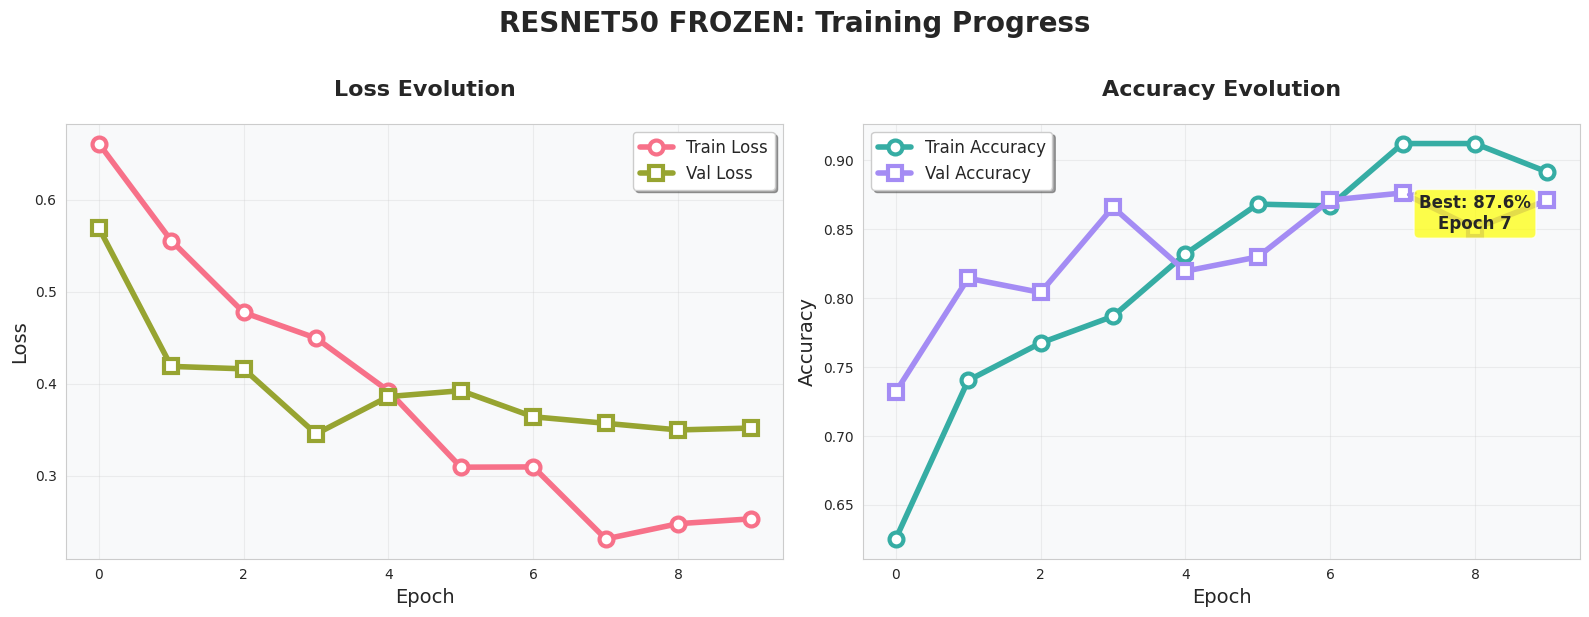

RESNET50 FROZEN РЕЗУЛЬТАТЫ
Лучшая val_acc: 87.6% (эпоха 7)
Финальная val_acc: 87.1%
Лучшая val_f1: 85.3%
Эпох всего: 10


In [28]:
plot_training_metrics_pro(
    "logs/resnet50_frozen", version=0, model_name="RESNET50 FROZEN"
)


Создание ResNet50 Frozen Backbone...
Backbone заморожен: 23,508,032 параметров (НЕ обучаются)
Head (обучается): 1,185,026 параметров
Модель RESNET50 FROZEN загружена на устройство: cuda
Размер валидации: 194
Классы: ['AiArtData', 'RealArt']
Распределение классов: [107  87]


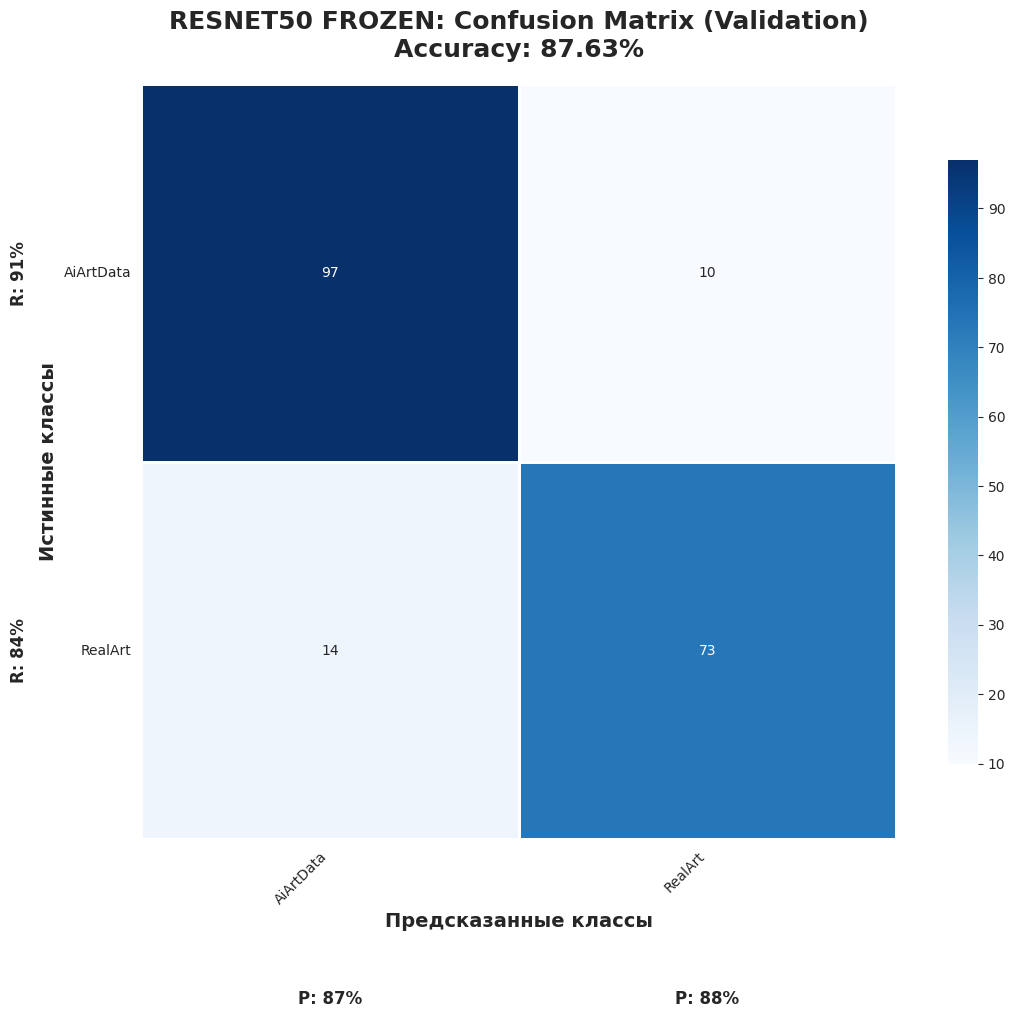


RESNET50 FROZEN | Метрики по классам
Класс                AiArtData       | RealArt        
Precision:             87.4% |   88.0%
Recall:                   90.7% |   83.9%
F1-score:                89.0% |   85.9%
Support:                107        | 87        


In [29]:
frozen_model = ResNet50Frozen.load_from_checkpoint(
    callbacks3[0].best_model_path
)
frozen_model.eval().to(device)

plot_confusion_matrix(
    frozen_model,
    val_loader,
    classes,
    model_name="RESNET50 FROZEN",
    device=device,
)


In [ ]:
metrics_df = pd.read_csv("logs/resnet50_frozen/version_0/metrics.csv")
best_val_acc = metrics_df["val_acc"].max()
model_name = f"SimpleCNN ({best_val_acc:.1%})"

print(f"Лучшая val_acc из логов: {model_name}")

Лучшая val_acc из логов: SimpleCNN (87.6%)


Создание ResNet50 Frozen Backbone...
Backbone заморожен: 23,508,032 параметров (НЕ обучаются)
Head (обучается): 1,185,026 параметров
Анализ ошибок ResNet50 Frozen (87.6%)
Всего ошибок: 24/194 (12.4%)


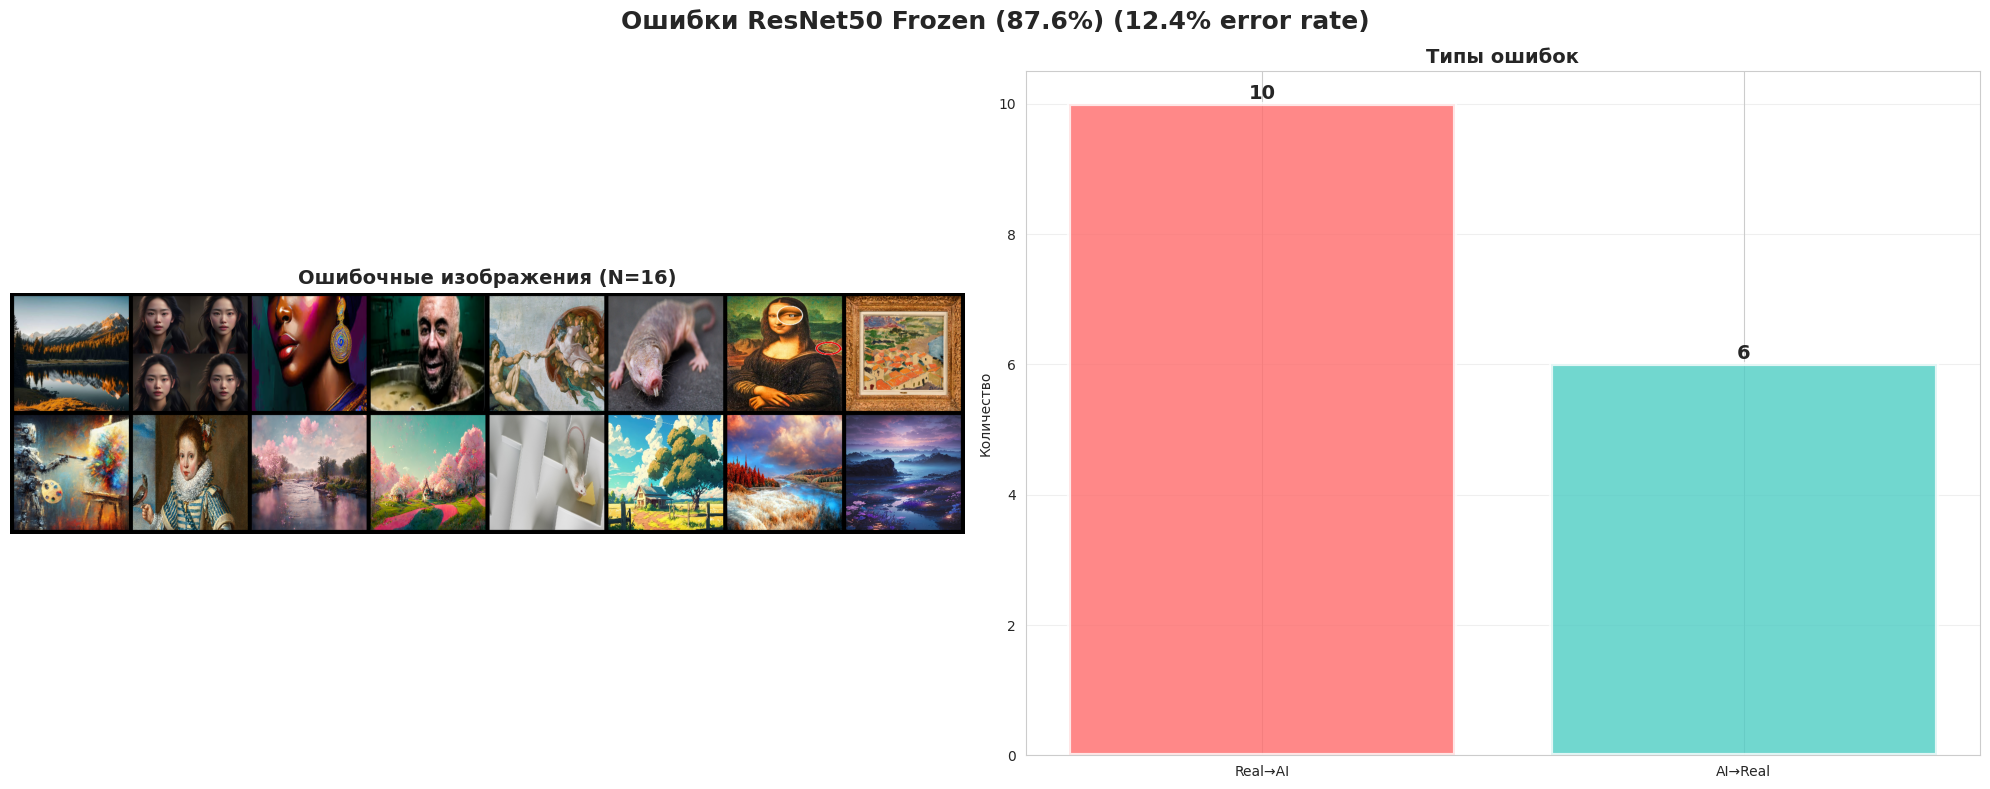


ПЕРВЫЕ 8 ОШИБОК:
----------------------------------------
#1: AiArtData → RealArt
#2: RealArt → AiArtData
#3: RealArt → AiArtData
#4: AiArtData → RealArt
#5: RealArt → AiArtData
#6: AiArtData → RealArt
#7: RealArt → AiArtData
#8: RealArt → AiArtData


In [31]:
analyze_errors(
    ResNet50Frozen,
    callbacks3[0].best_model_path,
    val_dataset,
    val_loader,
    classes,
    f"ResNet50 Frozen ({best_val_acc:.1%})",
)


# Выводы

Создание ResNet50 Full Train...
Backbone: 23,508,032 параметров
Head: 1,185,026 параметров
Бэкбон разморожен — все параметры обучаются
Создание ResNet50 Frozen Backbone...
Backbone заморожен: 23,508,032 параметров (НЕ обучаются)
Head (обучается): 1,185,026 параметров
РЕЗУЛЬТАТЫ СРАВНЕНИЯ
                   val_acc         f1 errors error_rate params
Cnn Art Vs Ai     74.74227  72.011656     49  25.257732   1.2M
Resnet50 Full     80.41237  77.919763     38  19.587629  24.7M
Resnet50 Frozen  87.628865  85.317522     24  12.371134   1.2M


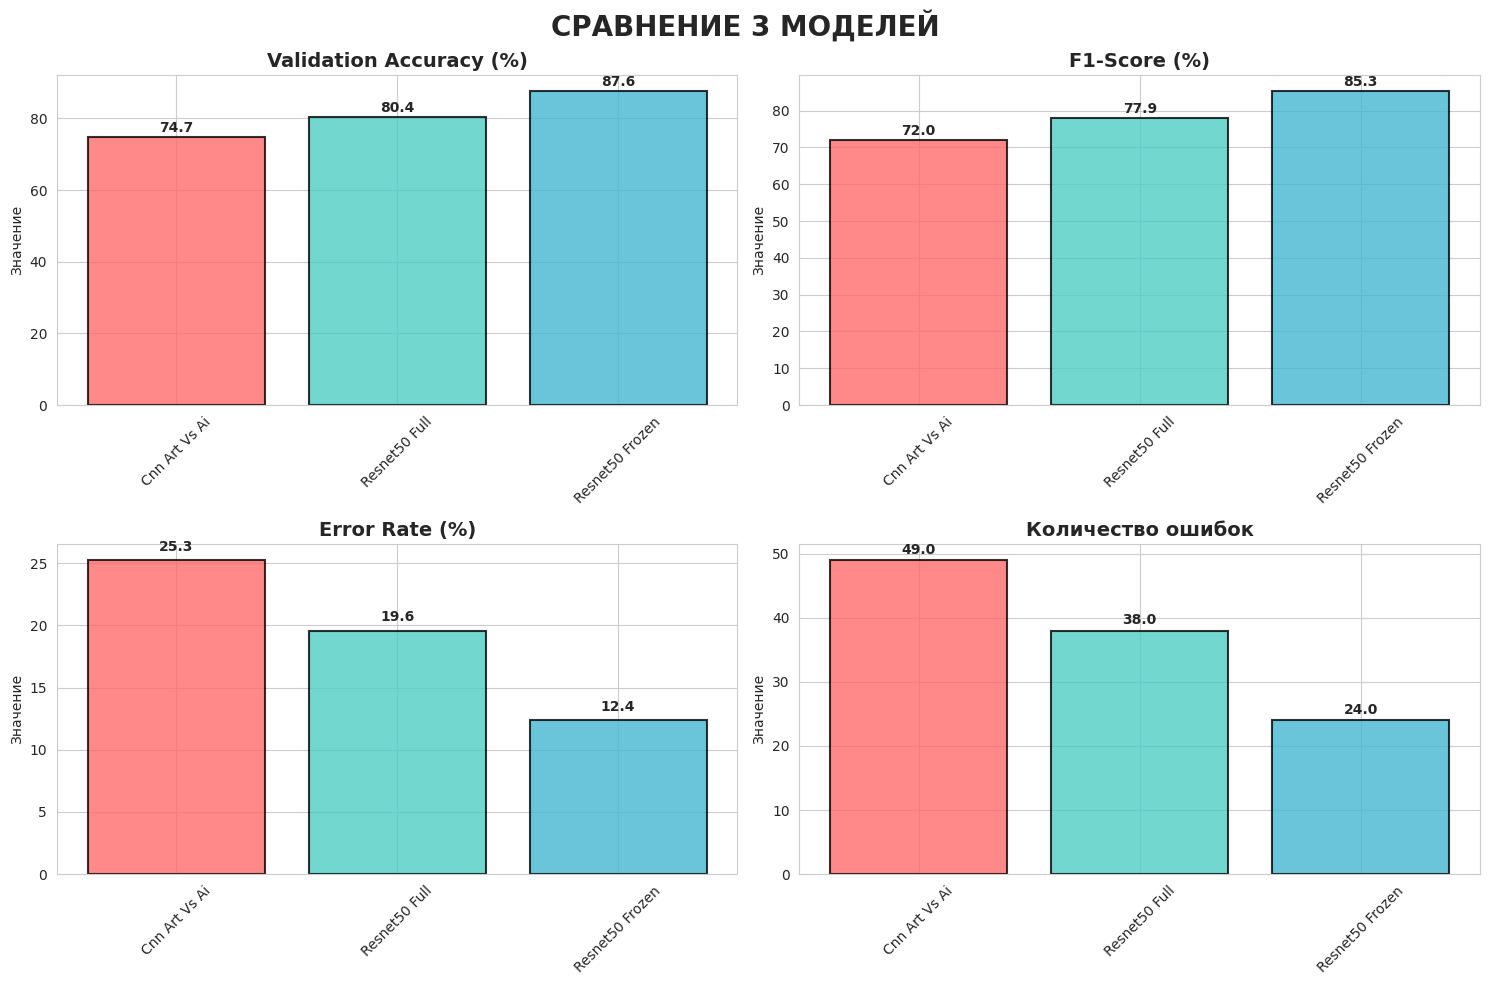

ВЫВОДЫ
1. ЛУЧШАЯ МОДЕЛЬ: Resnet50 Frozen (87.6%)
2. ХУДШАЯ МОДЕЛЬ: Cnn Art Vs Ai (74.7%)
3. ПРИРОСТ: +17.2%
4. ПАРАМЕТРЫ: 1.2M


In [34]:
def get_model_results(callbacks_list, model_classes, log_paths, val_loader):
    """Полный сбор из callbacks и логов"""
    results = {}

    for i, (callbacks, model_class, log_path) in enumerate(
        zip(callbacks_list, model_classes, log_paths)
    ):
        model_name = log_path.split("/")[-1].replace("_", " ").title()

        # Метрики из логов
        try:
            log_df = pd.read_csv(
                f"logs/{log_path}/version_0/metrics.csv"
            ).dropna(subset=["val_acc"])
            val_acc = log_df["val_acc"].max()
            f1 = log_df["val_f1"].max() if "val_f1" in log_df.columns else 0
            best_epoch = log_df.loc[log_df["val_acc"].idxmax(), "epoch"]
        except:
            val_acc = f1 = best_epoch = 0

        # Ошибки (вычисляем автоматически)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class.load_from_checkpoint(callbacks[0].best_model_path)
        model.eval().to(device)

        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                preds = logits.argmax(dim=1).cpu()
                all_preds.append(preds)
                all_targets.append(yb)

        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()
        errors = (all_preds != all_targets).sum()
        error_rate = errors / len(all_targets) * 100

        # Параметры модели
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(
            p.numel() for p in model.parameters() if p.requires_grad
        )
        params_str = (
            f"{trainable_params / 1e6:.1f}M"
            if trainable_params > 1e6
            else f"{trainable_params / 1e3:.0f}K"
        )

        results[model_name] = {
            "val_acc": val_acc * 100,
            "f1": f1 * 100,
            "errors": errors,
            "error_rate": error_rate,
            "params": params_str,
            "best_epoch": best_epoch,
            "total_params": total_params / 1e6,
        }

    return pd.DataFrame(results).T


callbacks_list = [callbacks, callbacks2, callbacks3]
model_classes = [SimpleCNN, ResNet50Full, ResNet50Frozen]
log_paths = ["cnn_art_vs_ai", "resnet50_full", "resnet50_frozen"]

# Автоматический сбор
df_results = get_model_results(
    callbacks_list, model_classes, log_paths, val_loader
)

print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("=" * 100)
display_df = df_results[
    ["val_acc", "f1", "errors", "error_rate", "params"]
].round(1)
print(display_df)

# График
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("СРАВНЕНИЕ 3 МОДЕЛЕЙ", fontsize=20, fontweight="bold")

metrics = ["val_acc", "f1", "error_rate", "errors"]
titles = [
    "Validation Accuracy (%)",
    "F1-Score (%)",
    "Error Rate (%)",
    "Количество ошибок",
]

colors = ["#ff6b6b", "#4ecdc4", "#45b7d1"]
for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i // 2, i % 2]
    bars = ax.bar(
        df_results.index,
        df_results[metric],
        color=colors,
        alpha=0.8,
        edgecolor="black",
        linewidth=1.5,
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Значение")
    ax.tick_params(axis="x", rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.5,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

# Выводы
print("ВЫВОДЫ")

best_model = df_results["val_acc"].idxmax()
worst_model = df_results["val_acc"].idxmin()
best_acc = df_results.loc[best_model, "val_acc"]
worst_acc = df_results.loc[worst_model, "val_acc"]

print(f"1. ЛУЧШАЯ МОДЕЛЬ: {best_model} ({best_acc:.1f}%)")
print(f"2. ХУДШАЯ МОДЕЛЬ: {worst_model} ({worst_acc:.1f}%)")
print(f"3. ПРИРОСТ: +{((best_acc - worst_acc) / worst_acc * 100):.1f}%")
print(f"4. ПАРАМЕТРЫ: {df_results.loc[best_model, 'params']}")


# Дополнительное задание (по желанию)


Сгенерируйте изображение с помощью любого современного инструмента генерации (например, Kandinsky, MidJourney, Stable Diffusion и т.п.).


Проверьте, как ваша лучшая модель классифицирует это изображение.



 ЗАГРУЗИТЕ ВАШЕ AI-ГЕНЕРИРОВАННОЕ ИЗОБРАЖЕНИЕ:


Saving 1.jpg to 1 (4).jpg
 Загружено: 1 (4).jpg
 test_tensor: torch.Size([1, 3, 224, 224])
Создание ResNet50 Full Train...
Backbone: 23,508,032 параметров
Head: 1,185,026 параметров
Бэкбон разморожен — все параметры обучаются

 РЕЗУЛЬТАТ:
   Предсказание: **AiArtData**
   Уверенность: **93.5%**
   Real: 93.5% | AI: 6.5%


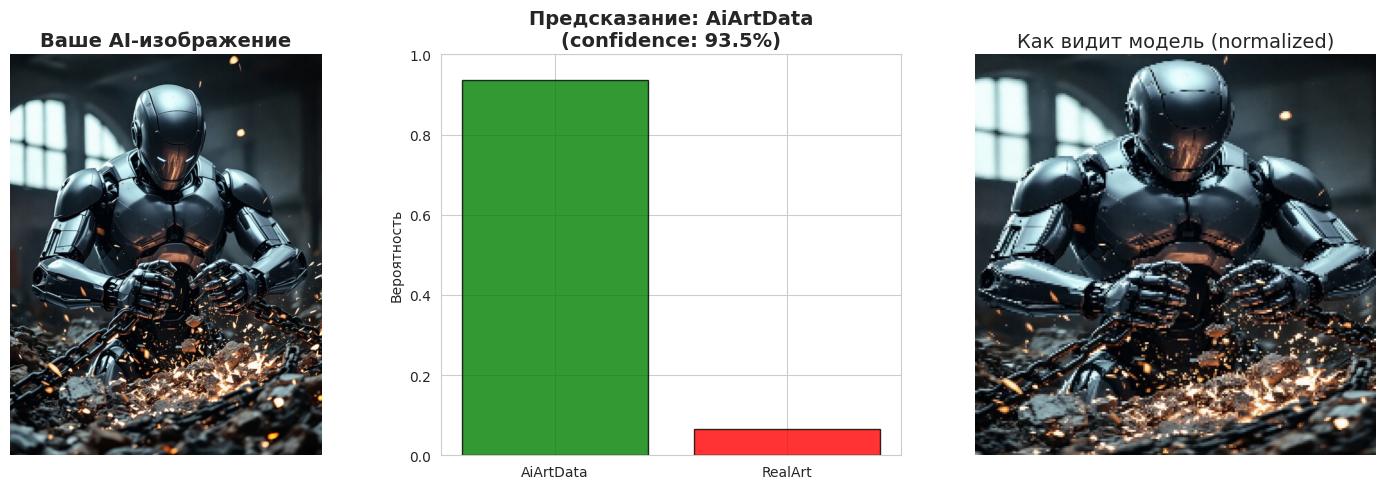

In [ ]:
# ЗАГРУЗКА ИЗОБРАЖЕНИЯ
print(" ЗАГРУЗИТЕ ВАШЕ AI-ГЕНЕРИРОВАННОЕ ИЗОБРАЖЕНИЕ:")
uploaded = files.upload()  # Кнопка загрузки появится

# Берем первое загруженное изображение
img_filename = list(uploaded.keys())[0]
test_img = Image.open(img_filename).convert("RGB")
print(f" Загружено: {img_filename}")

# TRANSFORMS (те же что для val)
test_transform = A.Compose(
    [
        A.Resize(height=256, width=256),
        A.CenterCrop(224, 224),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ]
)

test_image_np = np.array(test_img)
test_augmented = test_transform(image=test_image_np)
test_tensor = test_augmented["image"].unsqueeze(0)  # [1, 3, 224, 224]
print(f" test_tensor: {test_tensor.shape}")

# ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загружаем ЛУЧШУЮ модель (ResNet50 Full 81.4%)
best_model = ResNet50Full.load_from_checkpoint(callbacks2[0].best_model_path)
best_model.eval().to(device)

with torch.no_grad():
    test_tensor = test_tensor.to(device)
    logits = best_model(test_tensor)
    probs = F.softmax(logits, dim=1)
    pred = logits.argmax(dim=1).item()
    confidence = probs.max().item()

print(f"\n РЕЗУЛЬТАТ:")
print(f"   Предсказание: **{classes[pred]}**")
print(f"   Уверенность: **{confidence:.1%}**")
print(f"   Real: {probs[0][0]:.1%} | AI: {probs[0][1]:.1%}")

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(15, 5))

# Оригинал
plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title("Ваше AI-изображение", fontsize=14, fontweight="bold")
plt.axis("off")

# Барчарт вероятностей
plt.subplot(1, 3, 2)
plt.bar(
    classes,
    probs[0].cpu().numpy(),
    color=["green", "red"],
    alpha=0.8,
    edgecolor="black",
)
plt.title(
    f"Предсказание: {classes[pred]}\n(confidence: {confidence:.1%})",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Вероятность")
plt.ylim(0, 1)

# Denormalized версия (как видит модель)
plt.subplot(1, 3, 3)
img_denorm = test_tensor.squeeze(0).cpu()
img_denorm = (
    img_denorm * torch.tensor(STD)[:, None, None]
    + torch.tensor(MEAN)[:, None, None]
)
img_denorm = torch.clamp(img_denorm, 0, 1)
plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.title("Как видит модель (normalized)", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()